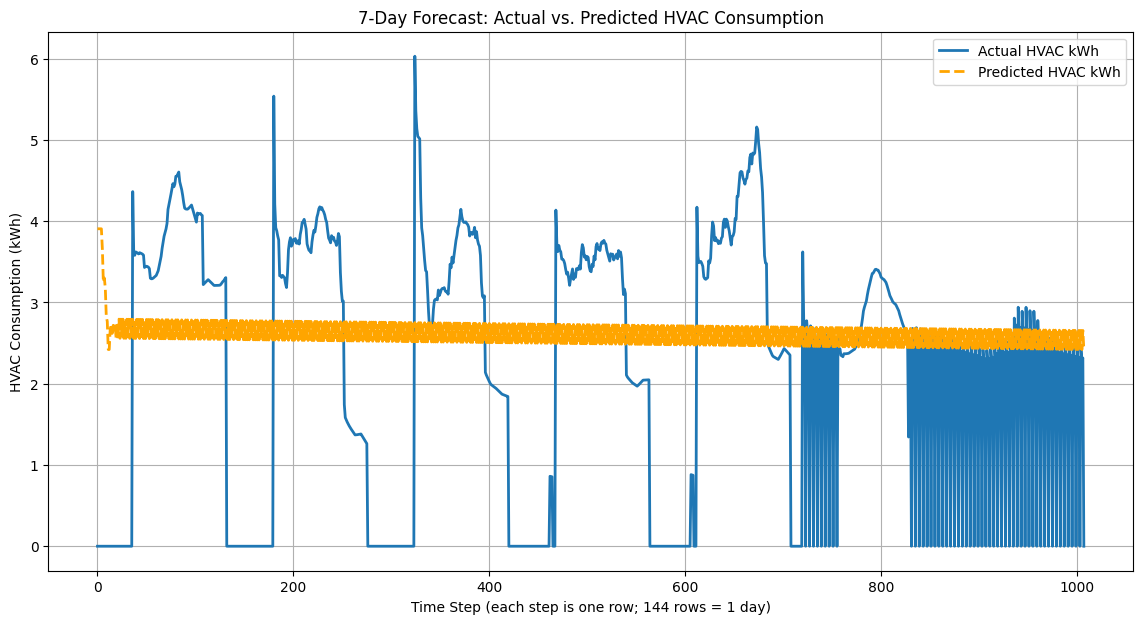

In [12]:
import boto3
import io
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
region = "ca-central-1"
bucket = "dana-minicapstone-ca"
test_key = "data/hvac_test.csv"
forecast_key = "data/hvac_forecast.csv"

# Define the number of rows per day and forecast horizon
rows_per_day = 144
forecast_days = 7
forecast_horizon = rows_per_day * forecast_days  # 144 * 7 = 1008 rows

# Create an S3 client in ca-central-1
s3 = boto3.client('s3', region_name=region)

# Read hvac_test.csv from S3 (which contains historical/actual values)
response_test = s3.get_object(Bucket=bucket, Key=test_key)
test_csv = response_test['Body'].read().decode('utf-8')
hvac_test_df = pd.read_csv(io.StringIO(test_csv))

# Read hvac_forecast.csv from S3 (which contains predicted values)
response_forecast = s3.get_object(Bucket=bucket, Key=forecast_key)
forecast_csv = response_forecast['Body'].read().decode('utf-8')
hvac_forecast_df = pd.read_csv(io.StringIO(forecast_csv))

# Extract only the last 7 days from hvac_test_df.
# If hvac_test_df has more rows than 7 days, we take only the most recent forecast_horizon rows
actual_df = hvac_test_df.iloc[-forecast_horizon:].reset_index(drop=True)

actual_df["HVAC_kWh"] = actual_df["Electricity:HVAC"] * 2.77778e-7

# Optionally, check that the actual data has the expected column (e.g., 'HVAC_kWh')
if 'HVAC_kWh' not in actual_df.columns:
    raise ValueError("The hvac_test.csv data does not contain the 'HVAC_kWh' column.")

# Plot the Actual vs. Predicted HVAC consumption.
plt.figure(figsize=(14, 7))
plt.plot(actual_df.index, actual_df["HVAC_kWh"], label="Actual HVAC kWh", linewidth=2)
plt.plot(hvac_forecast_df.index, hvac_forecast_df["Predicted_HVAC_kWh"], label="Predicted HVAC kWh", linestyle="--", linewidth=2, color="orange")
plt.xlabel("Time Step (each step is one row; 144 rows = 1 day)")
plt.ylabel("HVAC Consumption (kWh)")
plt.title("7-Day Forecast: Actual vs. Predicted HVAC Consumption")
plt.legend()
plt.grid(True)
plt.show()


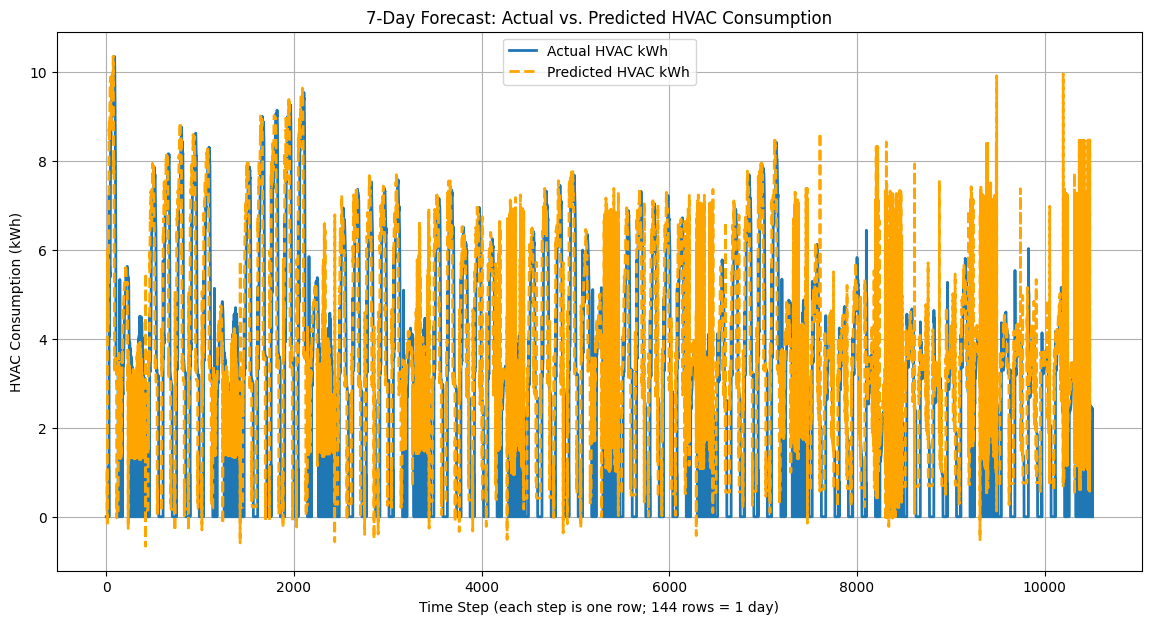

In [13]:
import boto3
import io
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
region = "ca-central-1"
bucket = "dana-minicapstone-ca"
test_key = "data/hvac_test.csv"
forecast_key = "data/hvac_pred.csv"

# Define the number of rows per day and forecast horizon
rows_per_day = 144
forecast_days = 7
forecast_horizon = rows_per_day * forecast_days  # 144 * 7 = 1008 rows

# Create an S3 client in ca-central-1
s3 = boto3.client('s3', region_name=region)

# Read hvac_test.csv from S3 (which contains historical/actual values)
response_test = s3.get_object(Bucket=bucket, Key=test_key)
test_csv = response_test['Body'].read().decode('utf-8')
hvac_test_df = pd.read_csv(io.StringIO(test_csv))

# Read hvac_forecast.csv from S3 (which contains predicted values)
response_forecast = s3.get_object(Bucket=bucket, Key=forecast_key)
forecast_csv = response_forecast['Body'].read().decode('utf-8')
hvac_forecast_df = pd.read_csv(io.StringIO(forecast_csv))

# Extract only the last 7 days from hvac_test_df.
# If hvac_test_df has more rows than 7 days, we take only the most recent forecast_horizon rows
# actual_df = hvac_test_df.iloc[-forecast_horizon:].reset_index(drop=True)
actual_df = hvac_test_df

actual_df["HVAC_kWh"] = actual_df["Electricity:HVAC"] * 2.77778e-7

# Optionally, check that the actual data has the expected column (e.g., 'HVAC_kWh')
if 'HVAC_kWh' not in actual_df.columns:
    raise ValueError("The hvac_test.csv data does not contain the 'HVAC_kWh' column.")

# Plot the Actual vs. Predicted HVAC consumption.
plt.figure(figsize=(14, 7))
plt.plot(actual_df.index, actual_df["HVAC_kWh"], label="Actual HVAC kWh", linewidth=2)
plt.plot(hvac_forecast_df.index, hvac_forecast_df["Predicted"], label="Predicted HVAC kWh", linestyle="--", linewidth=2, color="orange")
plt.xlabel("Time Step (each step is one row; 144 rows = 1 day)")
plt.ylabel("HVAC Consumption (kWh)")
plt.title("7-Day Forecast: Actual vs. Predicted HVAC Consumption")
plt.legend()
plt.grid(True)
plt.show()


the notebook where i made the model was working nicely 

hvac_data = pd.read_csv('hvac_model_zones.csv')
print('HVAC Data Shape:', hvac_data.shape)

hvac_data.columns = hvac_data.columns.str.replace(r"^b'|'$|\[.*?\]", "", regex=True)
hvac_data.head()

hvac_data = hvac_data.loc[hvac_data['Environment:Site Day Type Index'] != 0]
hvac_data["HVAC_kWh"] = hvac_data["Electricity:HVAC"] * 2.77778e-7

occupant_cols = [col for col in hvac_data.columns if 'Occupant' in col]
hvac_data["TotalOccupantCount"] = hvac_data[occupant_cols].sum(axis=1)

time_shifts = [0.5, 1, 1.5, 2]

for h in time_shifts:
    steps = int(h * 6)
    hvac_data[f"Occ_minus{int(h*60)}"] = hvac_data["TotalOccupantCount"].shift(steps)

for h in time_shifts:
    steps = int(h * 6)
    hvac_data[f"Occ_plus{int(h*60)}"] = hvac_data["TotalOccupantCount"].shift(-steps)


def map_day_type(x):
    if x in [0, 6, 7]:
        return 1
    else:
        return 0

hvac_data["WeekendOrHoliday"] = hvac_data["Environment:Site Day Type Index"].apply(map_day_type)


hvac_data = hvac_data.dropna()

features = ['HVAC_kWh']
target = 'HVAC_kWh'


def compute_metrics(test_data,forecast_mean):
    mae = mean_absolute_error(test_data, forecast_mean)
    mse = mean_squared_error(test_data, forecast_mean)
    rmse = np.sqrt(mse)


    metrics = {
        "mae":mae,
        "mse":mse,
        "rmse":rmse
    }

    return metrics


print(hvac_data.shape)

train_size = int(len(hvac_data) * 0.8)
train_data = hvac_data['HVAC_kWh'][:train_size]
test_data = hvac_data['HVAC_kWh'][train_size:]

X_train = np.arange(len(train_data)).reshape(-1, 1) 
y_train = train_data.values

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_fit = linear_model.predict(X_train)

residuals = y_train - y_fit

lags = 5
X_resid = np.array([residuals[i - lags:i] for i in range(lags, len(residuals))])
y_resid = residuals[lags:]


xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3)
xgb_model.fit(X_resid, y_resid)

resid_predictions = xgb_model.predict(X_resid)

y_fit_boosted = y_fit[lags:] + resid_predictions

X_test = np.arange(len(train_data), len(train_data) + len(test_data)).reshape(-1, 1)
y_pred = linear_model.predict(X_test)

X_test_resid = np.array([test_data.values[i - lags:i] - y_pred[i - lags:i] for i in range(lags, len(test_data))])
resid_test_predictions = xgb_model.predict(X_test_resid)

y_pred_boosted = y_pred[lags:] + resid_test_predictions

import matplotlib.pyplot as plt


plt.figure(figsize=(30, 10))

plt.plot(train_data.index, train_data, label='Training data', color='blue', linewidth=5)
plt.plot(train_data.index[-len(y_fit_boosted):], y_fit_boosted, label='Training predictions', color='red', linestyle='--', linewidth=2)

plt.plot(test_data.index, test_data, label='Test data', color='green', linewidth=5)
plt.plot(test_data.index[-len(y_pred_boosted):], y_pred_boosted, label='Test predictions', color='orange', linestyle='--', linewidth=2)

plt.legend()
plt.title('Predictions with hybrid model: LinearRegression + XGBoost')
plt.ylabel('Consumption')
plt.grid(True)
plt.tight_layout()

plt.show()
